# OCR Test for BelHisFirm, DPI test

In [1]:
!pip install jiwer levenshtein transformers accelerate bitsandbytes Pillow opencv-python python-doctr[viz] qwen_vl_utils

## Downsampling of image

In [32]:
from PIL import Image

full_res = Image.open("test/test-Yves_026_None.png")

w, h = full_res.size

# Compute new size for 300 DPI (75% of original)
scale_factor = 300 / 400  # = 0.75
new_width = int(w * scale_factor)
new_height = int(h * scale_factor)

resampled_res = full_res.resize((new_width, new_height), resample=Image.LANCZOS)

# OCR on EXACT same bounding boxes

In [33]:
import cv2 as cv
import json
import numpy as np
from doctr.models import detection_predictor
import base64

model = detection_predictor('db_resnet50', pretrained=True, assume_straight_pages=False, preserve_aspect_ratio=True)

full_res_crops = []
resampled_res_crops = []

# Convert PIL image to OpenCV format
full_res_cv = cv.cvtColor(np.array(full_res), cv.COLOR_RGB2BGR)
resampled_res_cv = cv.cvtColor(np.array(resampled_res), cv.COLOR_RGB2BGR)

out = model([full_res_cv])
words_array = out[0]['words']

def clamp_box(x0, y0, x1, y1, image_width, image_height):
    x0, x1 = sorted([max(0, min(x0, image_width - 1)), max(0, min(x1, image_width - 1))])
    y0, y1 = sorted([max(0, min(y0, image_height - 1)), max(0, min(y1, image_height - 1))])
    return x0, y0, x1, y1

for i, box in enumerate(words_array):
    
    # Extract and denormalize the four bounding box coordinates
    x1 = int(box[0][0] * w)
    y1 = int(box[0][1] * h)
    x2 = int(box[2][0] * w)
    y2 = int(box[2][1] * h)

    # Clamp the bounding box coordinates to the image dimensions
    x1, y1, x2, y2 = clamp_box(x1, y1, x2, y2, full_res_cv.shape[1], full_res_cv.shape[0])

    # Crop the full resolution image
    full_res_crop = full_res_cv[y1:y2, x1:x2]
    _, buffer = cv.imencode('.png', full_res_crop)
    encoded_image = base64.b64encode(buffer).decode('utf-8')
    full_res_crops.append(encoded_image)
    
    # Crop the resampled image
    resampled_res_crop = resampled_res_cv[int(y1 * scale_factor):int(y2 * scale_factor), int(x1 * scale_factor):int(x2 * scale_factor)]
    _, buffer = cv.imencode('.png', resampled_res_crop)
    encoded_image = base64.b64encode(buffer).decode('utf-8')
    resampled_res_crops.append(encoded_image)

## Run OCR

In [34]:
from transformers import Qwen2VLForConditionalGeneration, AutoTokenizer, AutoProcessor
from qwen_vl_utils import process_vision_info
import base64

full_res_text = []
resampled_res_text = []


model = Qwen2VLForConditionalGeneration.from_pretrained("Qwen/Qwen2-VL-7B-Instruct", torch_dtype="auto", device_map="auto")
processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct", min_pixels=128 * 28 * 28, max_pixels=512 * 28 * 28)

loop_list = [resampled_res_crops, full_res_crops]


for idx, list in enumerate(loop_list):
    if idx == 0:
        print("Running OCR on resampled crops...")
    else:
        print("Running OCR on full resolution crops...")

    for i, crop in enumerate(list):
        prompt = (f"Transcribe the word. Return only the word, no other text.")
        message = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": f"data:image/png;base64,{crop}"},
                    {"type": "text", "text": prompt},
                ],
            }
        ]
        
        text = processor.apply_chat_template(message, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(message)
        inputs = processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        )
        inputs = inputs.to("cuda")

        generated_ids = model.generate(**inputs, max_new_tokens=12)
        generated_ids_trimmed = [
            out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]
        text = processor.batch_decode(
            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )

        if i % 50 == 0:
            print(f"Step: {i}")
            if idx == 0:
                print(f"Resampled OCR: {text[0]}")
            else:
                print(f"Full Res OCR: {text[0]}")
        
        if idx == 0:
            resampled_res_text.append(text[0])
        else:
            full_res_text.append(text[0])

Loading checkpoint shards: 100%|██████████| 5/5 [00:01<00:00,  3.06it/s]


Running OCR on resampled crops...
Step: 0
Resampled OCR: Delbauve
Step: 50
Resampled OCR: ca
Step: 100
Resampled OCR: du
Step: 150
Resampled OCR: la
Step: 200
Resampled OCR: 2
Step: 250
Resampled OCR: de
Step: 300
Resampled OCR: une
Step: 350
Resampled OCR: directeur
Step: 400
Resampled OCR: capital
Step: 450
Resampled OCR: chiffre
Step: 500
Resampled OCR: être
Step: 550
Resampled OCR: anonyme
Step: 600
Resampled OCR: pertes
Step: 650
Resampled OCR: répartir
Step: 700
Resampled OCR: de
Step: 750
Resampled OCR: 1882
Running OCR on full resolution crops...
Step: 0
Full Res OCR: Delbouye
Step: 50
Full Res OCR: ca
Step: 100
Full Res OCR: du
Step: 150
Full Res OCR: la
Step: 200
Full Res OCR: 2
Step: 250
Full Res OCR: de
Step: 300
Full Res OCR: une
Step: 350
Full Res OCR: directeur
Step: 400
Full Res OCR: capital
Step: 450
Full Res OCR: chiffre
Step: 500
Full Res OCR: être
Step: 550
Full Res OCR: anonyme
Step: 600
Full Res OCR: pertes
Step: 650
Full Res OCR: répartir
Step: 700
Full Res OCR: 

In [35]:
import torch 
import gc

del model
del processor

torch.cuda.empty_cache()
torch.cuda.ipc_collect()
gc.collect()

22960

# Validate

## Import validation data from VIA 

In [5]:
import json

with open("test/via_project_7Aug2025_12h18m.json", "r", encoding="utf-8") as f:
    json_data = f.read()

data = json.loads(json_data)

# Extract text from each region
image_key = next(iter(data['_via_img_metadata']))
regions = data['_via_img_metadata'][image_key]['regions']

# Build the list of text entries
validation_words = [region['region_attributes'].get('text', '') for region in regions]

In [ ]:
# CER
from jiwer import cer

ref = ' '.join(validation_words)
fourhundred = ' '.join(full_res_text)
threehundred = ' '.join(resampled_res_text)

cer_fourhundred = cer(ref, fourhundred)
cer_threehundred = cer(ref, threehundred)

print(f"CER FourHundred: {cer_fourhundred}")
print(f"CER ThreeHundred: {cer_threehundred}")

CER FourHundred: 0.0193058568329718
CER ThreeHundred: 0.02668112798264642


In [12]:
resamples_wrong = 0
full_wrong = 0

for idx, word in enumerate(validation_words):
    if word != resampled_res_text[idx] and word != full_res_text[idx]:
        print(f"Full mismatch at index {idx}: {word} != {full_res_text[idx]} and {resampled_res_text[idx]}")
        full_wrong += 1
        resamples_wrong += 1
    if word != resampled_res_text[idx] and word == full_res_text[idx]:
        print(f"Resampled mismatch at index {idx}: {word} != {resampled_res_text[idx]} but full is correct {full_res_text[idx]}")
        resamples_wrong += 1
    if word == resampled_res_text[idx] and word != full_res_text[idx]:
        print(f"Full mismatch at index {idx}: {word} == {full_res_text[idx]} but resample is correct {resampled_res_text[idx]}")
        full_wrong += 1

print(f"Total mismatches in resampled: {resamples_wrong}")
print(f"Total mismatches in full resolution: {full_wrong}")

Full mismatch at index 0: Delbauve == Delbouye but resample is correct Delbauve
Full mismatch at index 1: du != due and due
Full mismatch at index 4: du != due and due
Full mismatch at index 6: à != 3 and a
Full mismatch at index 7: du == due but resample is correct du
Resampled mismatch at index 11: la != clay but full is correct la
Full mismatch at index 12: à != 2 and 2
Full mismatch at index 18: à != 人 and 人
Full mismatch at index 23: à != 3 and 3
Full mismatch at index 27: la != class and class
Full mismatch at index 33: à != 3 and a
Resampled mismatch at index 38: acte != acte. but full is correct acte
Full mismatch at index 44: à != 2 and 2
Full mismatch at index 45: tout == tou but resample is correct tout
Full mismatch at index 50: à != ca and ca
Full mismatch at index 52: ou != you and out
Resampled mismatch at index 58: vingt != ving but full is correct vingt
Full mismatch at index 59: terme != term and term
Resampled mismatch at index 66: Art != Art. but full is correct Art

In [13]:
from jiwer import wer

ref = ' '.join(validation_words)
fourhundred_wer = ' '.join(full_res_text)
threehundred_wer = ' '.join(resampled_res_text)

wer_fourhundred = wer(ref, fourhundred_wer)
wer_threehundred = wer(ref, threehundred_wer)

print(f"WER FourHundred: {wer_fourhundred}")
print(f"WER ThreeHundred: {wer_threehundred}")

WER FourHundred: 0.08365508365508366
WER ThreeHundred: 0.12612612612612611


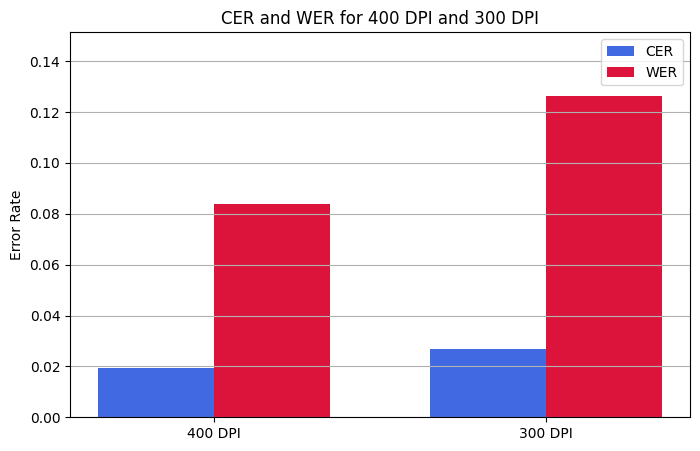

In [ ]:
import matplotlib.pyplot as plt

labels = ["400 DPI", "300 DPI"]
cer_values = [cer_fourhundred, cer_threehundred]
wer_values = [wer_fourhundred, wer_threehundred]

x = range(len(labels))

plt.figure(figsize=(8, 5))
bar_width = 0.35
plt.bar([i - bar_width/2 for i in x], cer_values, width=bar_width, label='CER', color='royalblue')
plt.bar([i + bar_width/2 for i in x], wer_values, width=bar_width, label='WER', color='crimson')
plt.xticks(x, labels)
plt.ylabel("Error Rate")
plt.title("CER and WER for 400 DPI and 300 DPI SAME bounding boxes")
plt.ylim(0, max(cer_values + wer_values) * 1.2)
plt.grid(axis='y')
plt.legend()
plt.show()


In [ ]:
import re

# Filter lists to only words containing digits

validation_digits = []
threehundred_digits = []
fourhundred_digits = []

for idx, box in enumerate(validation_words):
    if re.search(r'\d', box):
        validation_digits.append(validation_words[idx])
        threehundred_digits.append(resampled_res_text[idx])
        fourhundred_digits.append(full_res_text[idx])

ref_digits_str = ' '.join(validation_digits)
threehundred_digits_str = ' '.join(threehundred_digits)
fourhundred_digits_str = ' '.join(fourhundred_digits)

cer_fourhundred_digits = cer(ref, fourhundred_digits_str)
cer_threehundred_digits = cer(ref, threehundred_digits_str)

print(f"CER FourHundred: {cer_fourhundred_digits}")
print(f"CER ThreeHundred: {cer_threehundred_digits}")

wer_fourhundred_digits = wer(ref, fourhundred_digits_str)
wer_threehundred_digits = wer(ref, threehundred_digits_str)

print(f"WER FourHundred: {wer_fourhundred_digits}")
print(f"WER ThreeHundred: {wer_threehundred_digits}")


CER FourHundred: 0.9086767895878525
CER ThreeHundred: 0.9095444685466377
WER FourHundred: 0.8803088803088803
WER ThreeHundred: 0.888030888030888


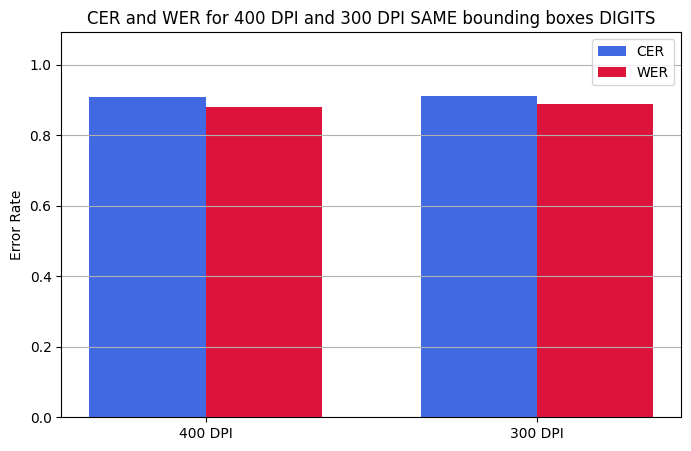

In [23]:
labels = ["400 DPI", "300 DPI"]
cer_values = [cer_fourhundred_digits, cer_threehundred_digits]
wer_values = [wer_fourhundred_digits, wer_threehundred_digits]

x = range(len(labels))

plt.figure(figsize=(8, 5))
bar_width = 0.35
plt.bar([i - bar_width/2 for i in x], cer_values, width=bar_width, label='CER', color='royalblue')
plt.bar([i + bar_width/2 for i in x], wer_values, width=bar_width, label='WER', color='crimson')
plt.xticks(x, labels)
plt.ylabel("Error Rate")
plt.title("CER and WER for 400 DPI and 300 DPI SAME bounding boxes DIGITS")
plt.ylim(0, max(cer_values + wer_values) * 1.2)
plt.grid(axis='y')
plt.legend()
plt.show()

# OCR on image specific bounding boxes
Uses the previous Qwen Detection so run it as well

In [54]:
model = detection_predictor('db_resnet50', pretrained=True, assume_straight_pages=False, preserve_aspect_ratio=True)

resampled_res_cv = cv.cvtColor(np.array(resampled_res), cv.COLOR_RGB2BGR)

out = model([resampled_res_cv])
words_array = out[0]['words']

In [57]:
resize_specific_crops = []

h, w = resampled_res_cv.shape[:2]


for i, box in enumerate(words_array):
    
    # Extract and denormalize the four bounding box coordinates
    x1 = int(box[0][0] * w)
    y1 = int(box[0][1] * h)
    x2 = int(box[2][0] * w)
    y2 = int(box[2][1] * h)

    # Clamp the bounding box coordinates to the image dimensions
    x1, y1, x2, y2 = clamp_box(x1, y1, x2, y2, resampled_res_cv.shape[1], resampled_res_cv.shape[0])

    # Crop the full resolution image
    resize_specific_crop = resampled_res_cv[y1:y2, x1:x2]
    _, buffer = cv.imencode('.png', resize_specific_crop)
    encoded_image = base64.b64encode(buffer).decode('utf-8')
    resize_specific_crops.append(encoded_image)

In [58]:
model = Qwen2VLForConditionalGeneration.from_pretrained("Qwen/Qwen2-VL-7B-Instruct", torch_dtype="auto", device_map="auto")
processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct", min_pixels=128 * 28 * 28, max_pixels=512 * 28 * 28)

resize_specific_text = []

for i, crop in enumerate(resize_specific_crops):
        prompt = (f"Transcribe the word. Return only the word, no other text.")
        message = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": f"data:image/png;base64,{crop}"},
                    {"type": "text", "text": prompt},
                ],
            }
        ]
        
        text = processor.apply_chat_template(message, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(message)
        inputs = processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        )
        inputs = inputs.to("cuda")

        generated_ids = model.generate(**inputs, max_new_tokens=12)
        generated_ids_trimmed = [
            out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]
        text = processor.batch_decode(
            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )

        if i % 50 == 0:
             print(f"Resized OCR: {text[0]}")
    
        resize_specific_text.append(text[0])

Loading checkpoint shards: 100%|██████████| 5/5 [00:01<00:00,  3.16it/s]


Resized OCR: Delbauve
Resized OCR: ca
Resized OCR: du
Resized OCR: la
Resized OCR: 2
Resized OCR: de
Resized OCR: une
Resized OCR: directeur
Resized OCR: capital
Resized OCR: chiffre
Resized OCR: être
Resized OCR: anonyme
Resized OCR: pertes
Resized OCR: répartir
Resized OCR: ice
Resized OCR: 1882


In [59]:
import torch 
import gc

del model
del processor

torch.cuda.empty_cache()
torch.cuda.ipc_collect()
gc.collect()

1845

# Validate

In [60]:
# CER
from jiwer import cer

ref = ' '.join(validation_words)
resampled_specific = ' '.join(resize_specific_text)

resampled_specific = cer(ref, resampled_specific)

print(f"CER Resampled Specific: {resampled_specific}")

CER Resampled Specific: 0.030585683297180043


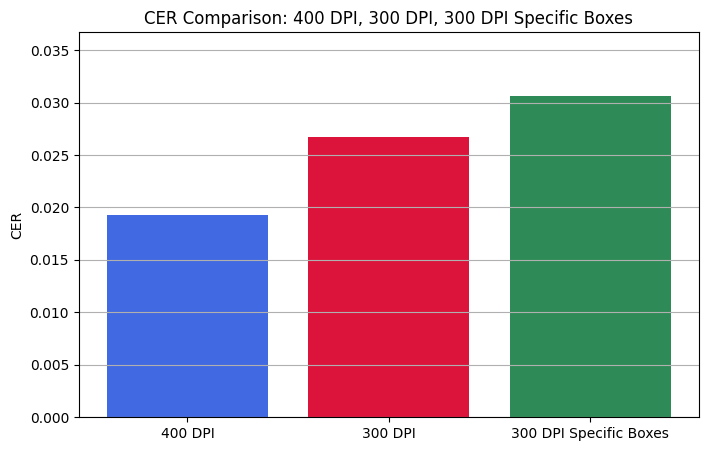

In [62]:
import matplotlib.pyplot as plt

labels = ["400 DPI", "300 DPI", "300 DPI Specific Boxes"]
cer_values = [cer_fourhundred, cer_threehundred, resampled_specific]

x = range(len(labels))

plt.figure(figsize=(8, 5))
plt.bar(x, cer_values, color=['royalblue', 'crimson', 'seagreen'])
plt.xticks(x, labels)
plt.ylabel("CER")
plt.title("CER Comparison: 400 DPI, 300 DPI, 300 DPI Specific Boxes")
plt.ylim(0, max(cer_values) * 1.2)
plt.grid(axis='y')
plt.show()